# **MÓDULO 13**
# Projeto - Fundamentos da Descoberta de Dados

Nesse projeto trabalharemos com a base de dados de produtos de um supermercado do Chile.
A ideia é que vocês apliquem os conceitos estatísticos vistos no último módulo, mais os conceitos de visualizações de dados através de gráficos e finalizem publicando no seu github!

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px

Faça a leitura dos dados do arquivo CSV:


Altere o código abaixo de acordo com seu diretório.

In [2]:
df = pd.read_csv("MODULO7_PROJETOFINAL_BASE_SUPERMERCADO.csv")

df.head(10)

,title,Marca,Preco_Normal,Preco_Desconto,Preco_Anterior,Desconto,Categoria
0,"Pack 12 un, Leche extra proteína 1 L",Loncoleche,19788,0,0,0,lacteos
1,"Pack 12 un, Leche chocolate receta original 1 L",Soprole,18228,0,0,0,lacteos
2,"Pack 12 un, Leche semidescremada chocolate 1 L",Soprole,18228,0,0,0,lacteos
3,"Pack 12 un, Leche semidescremada frutilla 1 L",Soprole,18228,0,0,0,lacteos
4,"Pack 12 un, Leche sin lactosa chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
5,"Pack 12 un, Leche sin lactosa frutilla 1 L",Loncoleche,17988,0,0,0,lacteos
6,"Pack 12 un, Leche saborizada light chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
7,"Pack 12 un, Leche saborizada frutilla 1 L",Colun,17388,0,0,0,lacteos
8,"Pack 12 un, Leche saborizada vainilla 1 L",Colun,17388,0,0,0,lacteos
9,"Pack 12 un, Leche saborizada manjar 1 L",Colun,17388,0,0,0,lacteos


Os campos do nosso dataframe são:

**Title:** Nome do produto.


**Marca:** A marca do produto.


**Preco_Normal:** O preço em que o produto costuma ser vendido quando não há desconto.


**Preco_Desconto:** O preço vendido após o desconto ser aplicado.


**Preco_Anterior:** Preço em que era comercializado o produto antes do desconto aplicado.


**Desconto:** Total de desconto aplicado.






As colunas que aparecem com valores 0 são para os produtos onde não tivemos descontos aplicados.


As categorias estão em espanhol!

# 1 - Traga a média e a mediana dos preços - coluna Preco_Normal - por categoria de produto.
# Identifique as categorias que parecem ter um valor de média abaixo ou acima da mediana.

In [3]:
# Seu código aqui para a média
df_mean = df.groupby("Categoria")["Preco_Normal"].mean()
df_mean

Categoria
belleza-y-cuidado-personal    1783.556485
comidas-preparadas            3095.043478
congelados                    2108.042553
frutas                        1724.473684
instantaneos-y-sopas           765.491228
lacteos                       2385.219239
verduras                      1343.296875
Name: Preco_Normal, dtype: float64

In [4]:
# Seu código aqui para a mediana
df_median = df.groupby("Categoria")["Preco_Normal"].median()
df_median

Categoria
belleza-y-cuidado-personal    1569.0
comidas-preparadas            3290.0
congelados                    1519.0
frutas                        1195.0
instantaneos-y-sopas           439.0
lacteos                        989.0
verduras                      1180.0
Name: Preco_Normal, dtype: float64

In [5]:
# diferença entre média e mediana
df_mean - df_median

Categoria
belleza-y-cuidado-personal     214.556485
comidas-preparadas            -194.956522
congelados                     589.042553
frutas                         529.473684
instantaneos-y-sopas           326.491228
lacteos                       1396.219239
verduras                       163.296875
Name: Preco_Normal, dtype: float64

Digite aqui as categorias:
- Acima da mediana: belleza-y-cuidado-personal, congelados, frutas, instantaneos-y-sopas, lacteos, verduras
- Abaixo da mediana: comidas-preparadas

# 2 - Traga o desvio padrão por categoria de produto.
# Qual o comportamento da média e mediana nas categorias com maior desvio?

In [6]:
# Seu código aqui
df_std = df.groupby("Categoria")["Preco_Normal"].agg(["mean", "median", "std"])
df_std["Diferença"] = (
    df_std["std"] - df_std["mean"]
)  # coluna para auxiliar na vizualização da distancia entre etd e mean
df_std

,mean,median,std,Diferença
Categoria,,,,
belleza-y-cuidado-personal,1783.556485,1569.0,2210.041719,426.485234
comidas-preparadas,3095.043478,3290.0,2019.911428,-1075.132051
congelados,2108.042553,1519.0,2111.539896,3.497343
frutas,1724.473684,1195.0,1639.151114,-85.322570
instantaneos-y-sopas,765.491228,439.0,1170.232869,404.741641
lacteos,2385.219239,989.0,3925.816164,1540.596925
verduras,1343.296875,1180.0,1012.699625,-330.597250


Digite nesse campo o comportamento que você identificou.
Na sessão de Lacteos, a Categoria onde o desvio padrão é maior, podemos perceber o quão distante a média e mediana estão uma da outra, enquanto a Categoria de Frutas, que tem um devio negativa por exemplo, a média e a mediana estão muito mais próximas.

# 3 - Plot um boxplot da distribuição do Preco_Normal para a categoria que você identificou que tem o maior desvio padrão. Como é a distribuição desses dados segundo o boxplot? Você identifica muitos outliers?

Dica: Para trazer apenas os dados da categoria que você deseja você pode usar o df.loc[df['Categoria'] == 'CATEGORIA ESCOLHIDA'

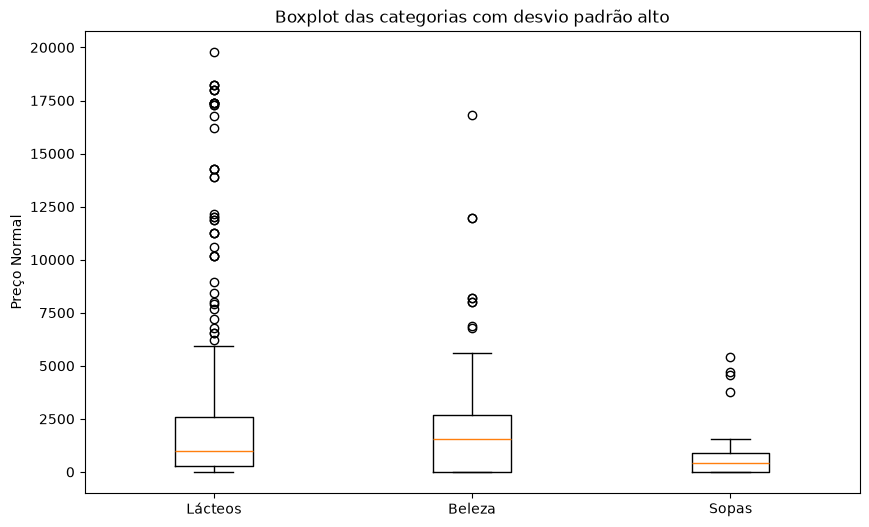

In [14]:
# Seu código aqui

# base box
lacteos = df.loc[df["Categoria"] == "lacteos"]["Preco_Normal"]
beleza = df.loc[df["Categoria"] == "belleza-y-cuidado-personal"]["Preco_Normal"]
sopas = df.loc[df["Categoria"] == "instantaneos-y-sopas"]["Preco_Normal"]

# grafico
plt.figure(figsize=(10, 6))
plt.boxplot([lacteos, beleza, sopas], tick_labels=["Lácteos", "Beleza", "Sopas"])
plt.title("Boxplot das categorias com desvio padrão alto")
plt.ylabel("Preço Normal")
plt.show()

Sim, temos muitos outliers. Nas categorias de lacteos e beleza é compreensivel, visto que ambos tem produtos "High end", como queijos importados ou mesmo produtos de cuidado com a pele, nmmo caso do setor de beleza, que podem chegar a valores muito elevados comparados a média. Quanto a sopas, presumo que se de por terem produtos extremamente baratos (como podemos notar pelo corpo do boxl=plot dele), então produtos em faixas de preço que fogem desse escopo super barato acabam se tornando outliers.

# 4 - Plote um gráfico de barras onde temos a média de descontos por categoria.

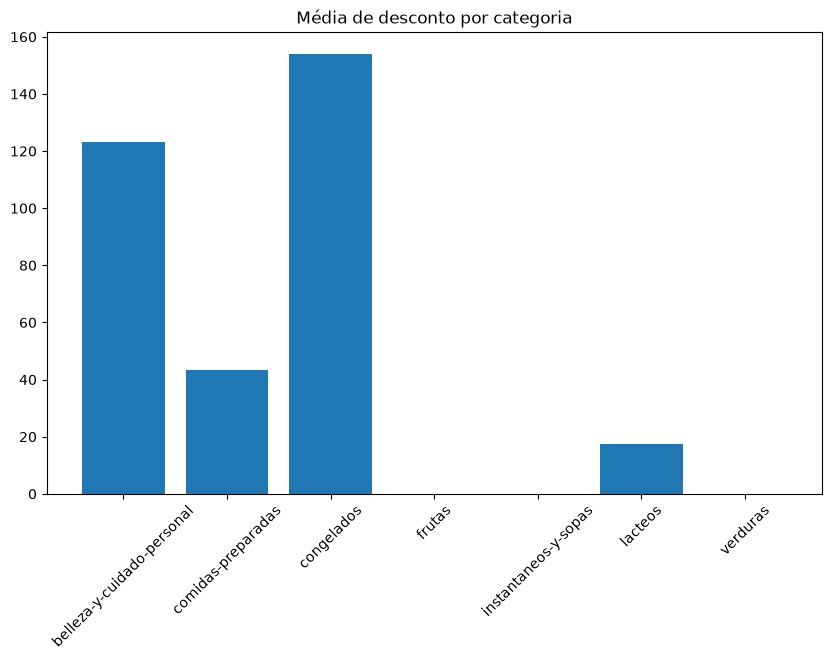

In [ ]:
# Seu código aqui
plt.figure(figsize=(10, 6))

df_desconto_mean = df.groupby("Categoria")["Desconto"].mean()

# grafico
plt.bar(df_desconto_mean.index, df_desconto_mean.values)
plt.title("Média de desconto por categoria")
plt.xticks(rotation=45)
plt.show()

# 5 - Plote um gráfico de mapa interativo agrupando os dados por categoria, marca e trazendo a média de desconto.

In [11]:
# Seu código aqui

# Agrupamento
df_grouped = df.groupby(["Categoria", "Marca"])["Desconto"].mean().reset_index()

# Plotagem do grafico
fig = px.treemap(
    df_grouped,
    path=[px.Constant("Todas as Categorias"), "Categoria", "Marca"],
    values="Desconto",
    title="Media de desconto por Marca e Categoria",
)
fig.update_traces(root_color="lightgrey")

fig.show()